# **Predicting Solar Energy Load in the Netherlands using Machine Learning Models and Hugging Face**
## **Emiliano Pedraza,  Physics Engineer**

Using Hugging Face to predict the electrical load [W] data in Edam, Netherlands. The dataset used is extracted from Dutch DSO Liander with weather data from OpenMeteo, curated by OpenSTEF and accessed through Hugging Face. The Electrical load (active power) measurements are from various types of infrastructure managed by Dutch DSO Liander, the largest regional electricity and gas Distribution System Operator (DSO) in the Netherlands. The electrical load i representative of how much load is being drawn or injected into the grid:
- A positive load means a feeder is drawing power from the grid, so customers connected to it are consuming more than they're generating.
- A negative load means a feeder is injecting power back into the grid, so local solar generation is exceeding local consumption at that moment.


Importing libraries

In [ ]:
import pandas as pd
import requests
import yaml
from pandas.core.reshape import merge
import random
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import size
from sklearn.ensemble import RandomForestRegressor

In [ ]:
pd.set_option("display.max_columns", None)

### Data Loading
Setting the location and loading the necessary data, including load measurements and various weather forecast data, from the Hugging Face dataset. This data will be used to train and evaluate our energy forecasting models.

In [ ]:
location=("OS Edam").replace(" ", "%20")
print(location)

OS%20Edam


In [ ]:
base_url = "https://huggingface.co/datasets/OpenSTEF/liander2024-energy-forecasting-benchmark/resolve/main"

load_data = pd.read_parquet(f"{base_url}/load_measurements/mv_feeder/{location}.parquet")
weather_data = pd.read_parquet(f"{base_url}/weather_measurements/mv_feeder/{location}.parquet")
weather_forecasts = pd.read_parquet(f"{base_url}/weather_forecasts/mv_feeder/{location}.parquet")
weather_forecasts_versioned = pd.read_parquet(f"{base_url}/weather_forecasts_versioned/mv_feeder/{location}.parquet")

In [ ]:
yaml_url = f"{base_url}/liander2024_targets.yaml"
response = requests.get(yaml_url)
liander_data = pd.DataFrame(yaml.safe_load(response.text))

In [ ]:
liander_location= liander_data[liander_data["name"]==location.replace("%20", " ")]
liander_location

,name,group_name,latitude,longitude,description,benchmark_start,benchmark_end,train_start,upper_limit,lower_limit
30,OS Edam,mv_feeder,52.512,5.048,MV feeder OS Edam,2024-03-01T00:00:00Z,2024-12-31T23:59:59Z,2024-01-01T00:00:00Z,1.396667e+06,-940000.0


### Filtering Data by Availability
The following block ensures that only data available at the time of the forecast is used. This is crucial for realistic forecasting scenarios, as we cannot use future information that wouldn't have been known at the time of prediction.

In [ ]:
def time_filter(df):
  return_df=df[df["timestamp"]>=df["available_at"]]
  return return_df.drop(columns=["available_at"])

In [ ]:
load_data_1= time_filter(load_data)
weather_forecasts_versioned_1= time_filter(weather_forecasts_versioned)

### Merging Load and Weather Forecasts
After filtering, the load data and versioned weather forecasts are merged based on their timestamps. This combined dataset, is the foundation for the following analysis, merging energy consumption with meteorological predictions.

In [130]:
merge= pd.merge(load_data_1, weather_forecasts_versioned_1, on="timestamp", how="inner")

In [131]:
merge.head(3)

,timestamp,load,temperature_2m,relative_humidity_2m,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_80m,wind_direction_10m,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance
0,2024-01-01 00:00:00+00:00,790000.000000,7.7175,81.314476,993.937195,100.0,37.162045,48.844715,215.537766,0.0,0.0,0.0,0.0
1,2024-01-01 00:15:00+00:00,790000.000000,7.5550,82.914001,994.036987,99.5,36.508251,47.671295,215.034454,0.0,0.0,0.0,0.0
2,2024-01-01 00:30:00+00:00,773333.333333,7.3925,84.513527,994.136841,99.0,35.854458,46.497871,214.531128,0.0,0.0,0.0,0.0


Manipulating the format of all relevant features and dropping null rows.

In [132]:
final_data=merge.dropna()
final_data["time_secs"]=final_data["timestamp"].astype("int64") // 10**9
final_data=final_data.drop(columns=["timestamp"])

/tmp/ipykernel_2087/1246945903.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data["time_secs"]=final_data["timestamp"].astype("int64") // 10**9


In [133]:
final_data.head(3)

,load,temperature_2m,relative_humidity_2m,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_80m,wind_direction_10m,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance,time_secs
0,790000.000000,7.7175,81.314476,993.937195,100.0,37.162045,48.844715,215.537766,0.0,0.0,0.0,0.0,1704067200
1,790000.000000,7.5550,82.914001,994.036987,99.5,36.508251,47.671295,215.034454,0.0,0.0,0.0,0.0,1704068100
2,773333.333333,7.3925,84.513527,994.136841,99.0,35.854458,46.497871,214.531128,0.0,0.0,0.0,0.0,1704069000


### Correlation Matrix
Before building models, we view the relationships between our features and the target variable of load. The correlation matrix helps visualize these relationships.

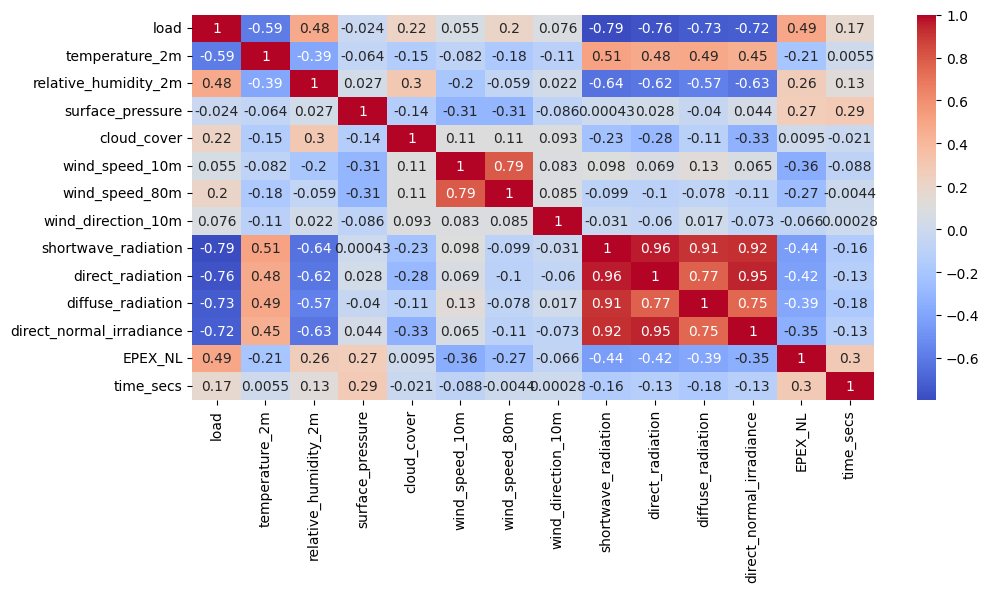

In [ ]:
correlation_matrix = final_data.corr()
plt.figure(figsize=(11, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

### Visualizing Key Relationships
These plots aim to visually explore the relationship load has with various parameters. These graphs can inform our decision on what features to choose to proceed with the splitting, training and fitting of the data.

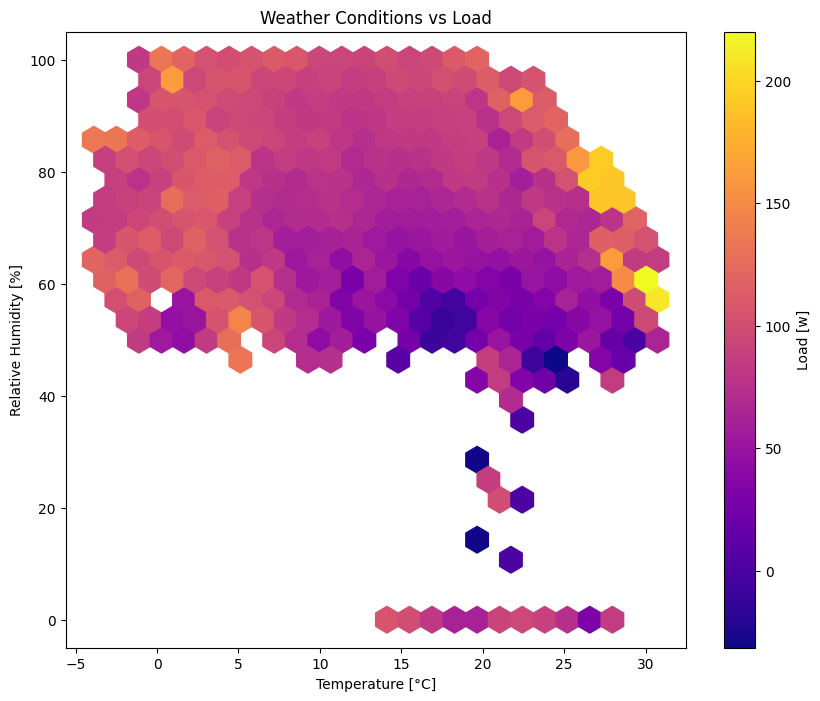

In [129]:
x_plt = final_data['temperature_2m'].values
y_plt = final_data['relative_humidity_2m'].values
z_plt = final_data['load'].values

fig, ax = plt.subplots(figsize=(10, 8))
hb = ax.hexbin(x_plt, y_plt, C=z_plt, reduce_C_function=np.mean, gridsize=25, cmap='plasma', mincnt=1)

ax.set_xlabel('Temperature [°C]')
ax.set_ylabel('Relative Humidity [%]')

cbar = fig.colorbar(hb)
cbar.set_label('Load [w]')

plt.title('Weather Conditions vs Load')
plt.show()

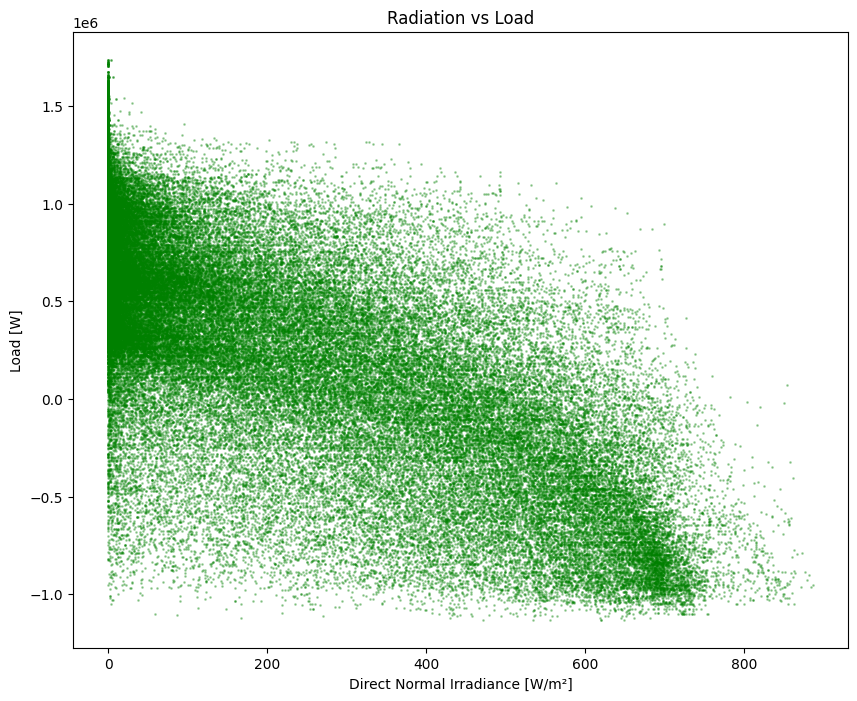

In [126]:
x_plt = final_data['direct_normal_irradiance'].values
y_plt = final_data['load'].values

fig, ax = plt.subplots(figsize=(10, 8))

plt.scatter(x_plt, y_plt, alpha=0.3, color='green', s=1)

ax.set_xlabel('Direct Normal Irradiance [W/m²]')
ax.set_ylabel('Load [W]')

plt.title('Radiation vs Load')
plt.show()

### Splitting

From the correlation matrix, we observe the following parameters are the ones which correlate the most with the target field of load:
- temperature_2m
- relative_humidity_2m
- shortwave_radiation
- direct_radiation -diffuse_radiation
- direct_normal_irradiance


---


Understanding the physical meaning behind these attributes can help out choose the best one:

- temperature_2m: The standard meteorological measurement for the air temperature 2 meters above surface.
- relative_humidity_2m: Similarly, this describes the relative humidity 2 meters above surface.
- shortwave_radiation: Light of short wavelengths, such as UV light. Given that UV light penetrates clouds, this radiation is closely correlated to the Direct Normal Irradiance.
- direct_radiation -diffuse_radiation: Sunlight that is scattered by atmospheric elements like dust or clouds.
- direct_normal_irradiance: The maximum sunlight quantity a panel receives when facing directly the sun and being unaffected by atmospheric elements. The UV light is part of all sunlight that makes it to the panel but this is the actual light in the wavelength the panel makes the most out of to displace electrons and create electricity.

All things considered, while perfect features to predict the load of energy produced by the panels, how good are these radiation features to practically predict the production of electricity? Is associating the production of electricity simplifying the whole thesis to "more sunlight, more electricity", which is a given, or is there actually something to be learned from fitting and predicting data using a radiation field?

We will conduct the fitting and predicting using two different sets of features to train the data and compare the outputs:


1- ["temperature_2m", "relative_humidity_2m", "cloud_cover"]

2- ["temperature_2m", "relative_humidity_2m", "cloud_cover", "direct_normal_irradiance"]


In [ ]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(final_data[["temperature_2m", "relative_humidity_2m", "cloud_cover", "wind_speed_80m"]], final_data["load"], test_size=0.3, random_state=42)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(final_data[["temperature_2m", "relative_humidity_2m", "cloud_cover", "wind_speed_80m", "direct_normal_irradiance"]], final_data["load"], test_size=0.3, random_state=42)

### Cross-validation, fitting and prediction


In [ ]:
# 1
scaler = StandardScaler()
ridge_cv = RidgeCV(cv=5)

X_train_scaled_1 = scaler.fit_transform(X_train_1)
X_test_scaled_1 = scaler.transform(X_test_1)
ridge_cv.fit(X_train_scaled_1, y_train_1)

y_pred_1 = ridge_cv.predict(X_test_scaled_1)
test_mse_1 = mean_squared_error(y_test_1, y_pred_1)
test_r2_1 = r2_score(y_test_1, y_pred_1)

scores_1 = cross_val_score(ridge_cv, X_train_scaled_1, y_train_1, cv=5)
print(scores_1)
print(test_mse_1)
print(test_r2_1)

[0.44284432 0.44634608 0.44691143 0.44409951 0.44091341]
142527553332.8589
0.44422242771241427


In [ ]:
# 2
scaler = StandardScaler()
ridge_cv = RidgeCV(cv=5)

X_train_scaled_2 = scaler.fit_transform(X_train_2)
X_test_scaled_2 = scaler.transform(X_test_2)
ridge_cv.fit(X_train_scaled_2, y_train_2)

y_pred_2 = ridge_cv.predict(X_test_scaled_2)
test_mse_2 = mean_squared_error(y_test_2, y_pred_2)
test_r2_2 = r2_score(y_test_2, y_pred_2)

scores_2 = cross_val_score(ridge_cv, X_train_scaled_2, y_train_2, cv=5)
print(scores_2)
print(test_mse_2)
print(test_r2_2)

[0.61974808 0.62610606 0.62804444 0.62880494 0.61457921]
97571012045.6332
0.6195277409012891


### RidgeCV Model Evaluation
Both Ridge Regression models show moderate performance, with R-squared values indicating the proportion of variance in the dependent variable predictable from the independent variables. Model 2, incorporating direct_normal_irradiance, shows a better fit, highlighting the importance of solar radiation for load prediction. However, the R-squared values are still relatively low for robust meteorological predictions.

### Random Forest Regressor prediction
We turn to Random Forest Regressor to find a better model to predict the data of load.

In [ ]:
print("Random Forest Model 1")
rf_pipeline_1 = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

rf_pipeline_1.fit(X_train_1, y_train_1)
y_pred_rf_1 = rf_pipeline_1.predict(X_test_1)

mse_rf_1 = mean_squared_error(y_test_1, y_pred_rf_1)
r2_rf_1 = r2_score(y_test_1, y_pred_rf_1)

print(f"Test MSE: {mse_rf_1}")
print(f"Test R-squared: {r2_rf_1}")

print("Random Forest Model 2")
rf_pipeline_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

rf_pipeline_2.fit(X_train_2, y_train_2)
y_pred_rf_2 = rf_pipeline_2.predict(X_test_2)

mse_rf_2 = mean_squared_error(y_test_2, y_pred_rf_2)
r2_rf_2 = r2_score(y_test_2, y_pred_rf_2)

print(f"Test MSE: {mse_rf_2}")
print(f"Test R-squared: {r2_rf_2}")

--- Random Forest Model 1 ---
Random Forest Model 1 Test MSE: 90038206215.18004
Random Forest Model 1 Test R-squared: 0.6489014615543458

--- Random Forest Model 2 ---
Random Forest Model 2 Test MSE: 57061401414.32999
Random Forest Model 2 Test R-squared: 0.7774925170060266


### Random Forest Regressor Evaluation
The Random Forest models demonstrate improved performance compared to Ridge Regression, with higher R-squared values.

### Random Forest Regressor as a Model to Predict Load Values using Available Weather Measurements and Direct Normal Radiation

We graph the predicted values of load for both Model 1 (only weather measurements) and Model 2 (weather measurements + direct normal radiation measurements).

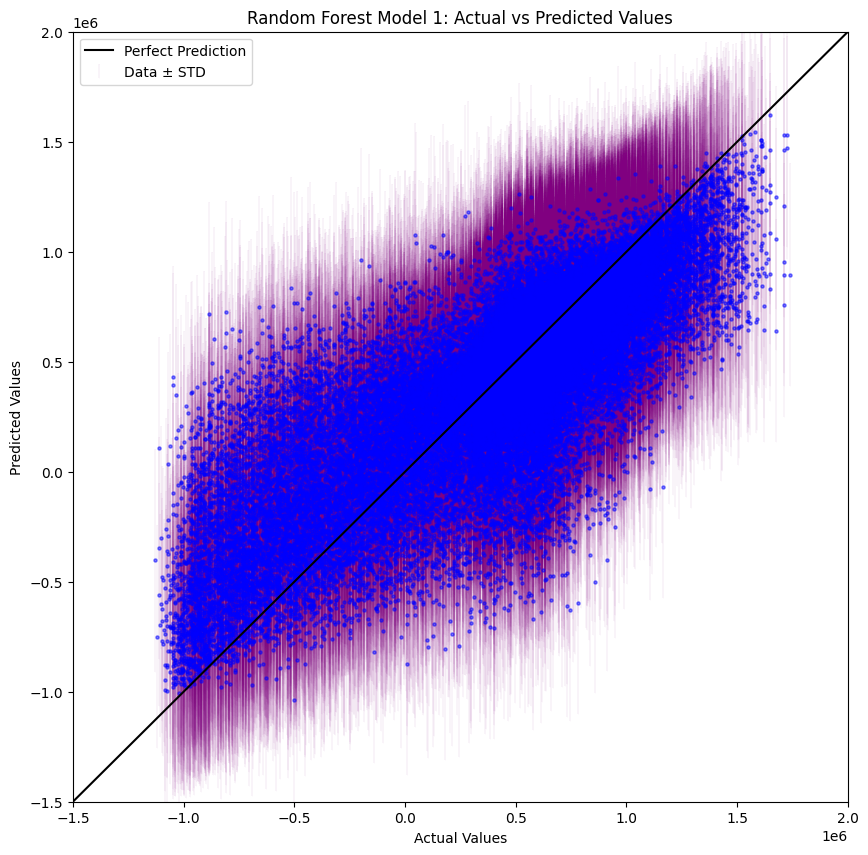

In [185]:
plt.figure(figsize=(10, 10))
plt.scatter(y_test_1, y_pred_rf_1, s=5, color="blue", alpha=0.5)
plt.title("Random Forest Model 1: Actual vs Predicted Values")
std_dev = np.std(y_test_1)
plt.errorbar(y_test_1, y_pred_rf_1, yerr=std_dev, capsize=0.06, capthick=0.06, ecolor='purple', label='Data ± STD', fmt='none', elinewidth=0.06, zorder=0)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.plot([-1.5e6, 2.0e6], [-1.5e6, 2.0e6], color='black', label='Perfect Prediction', zorder=3)
plt.xlim(left=-1.5e6, right=2.0e6)
plt.ylim(bottom=-1.5e6, top=2.0e6)
plt.legend()
plt.show()

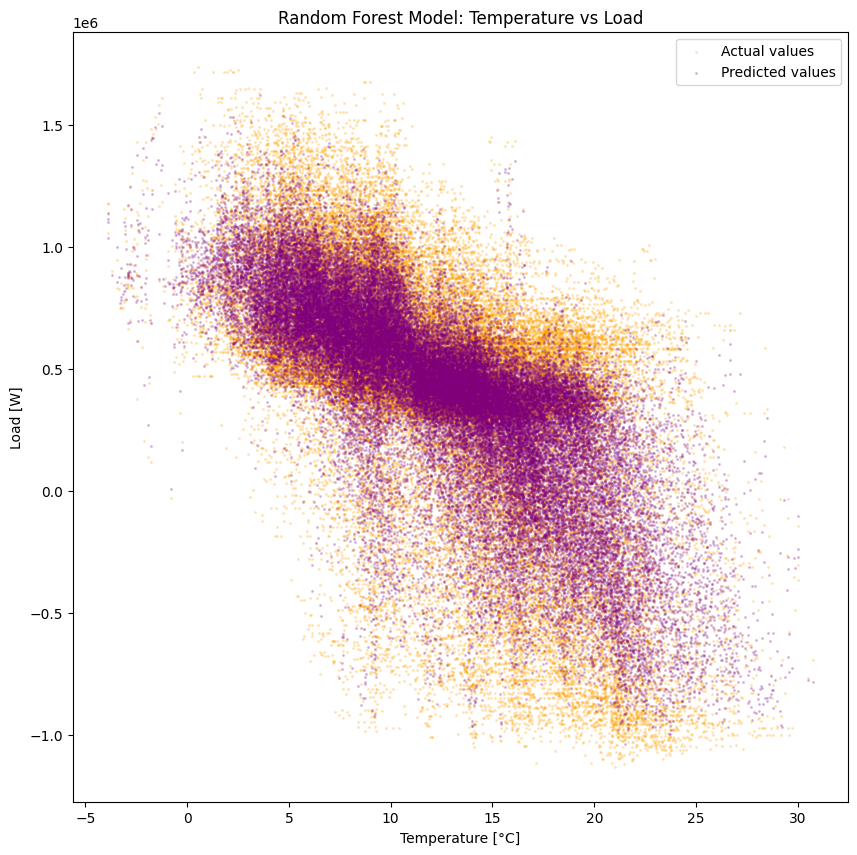

In [166]:
plt.figure(figsize=(10, 10))
plt.scatter(X_test_1['temperature_2m'], y_test_1, s=1.5, color="orange", alpha=0.2, label="Actual values")
plt.scatter(X_test_1['temperature_2m'], y_pred_rf_1, s=1.5, color="purple", alpha=0.2, label="Predicted values")
plt.title("Random Forest Model 1: Temperature vs Load")
plt.xlabel("Temperature [°C]")
plt.ylabel("Load [W]")
plt.legend()
plt.show()

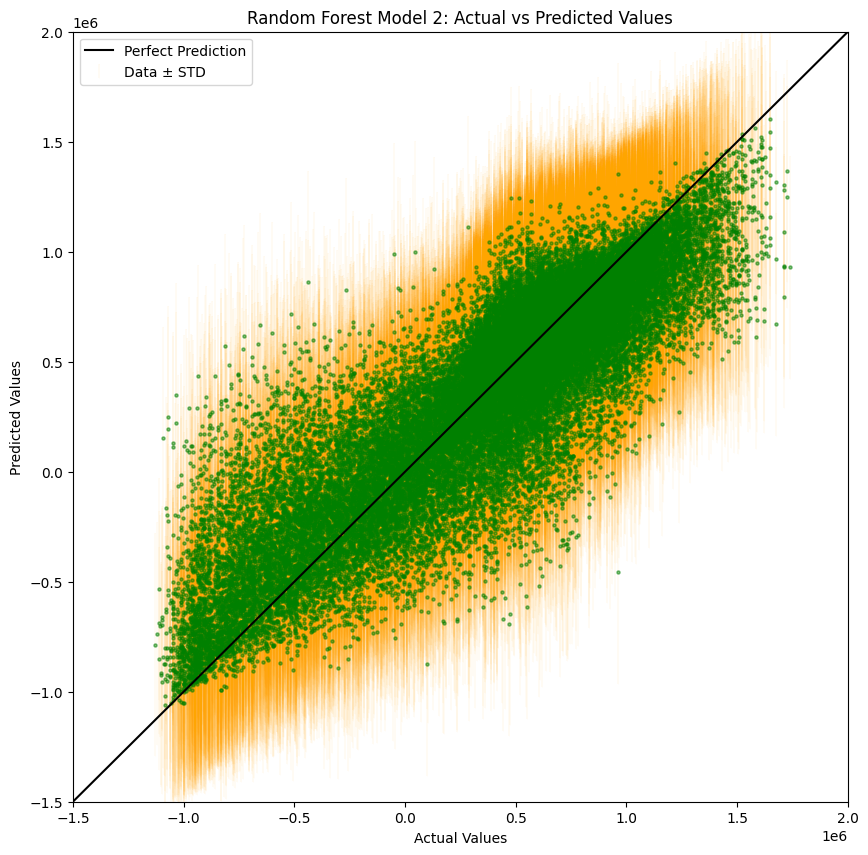

In [184]:
plt.figure(figsize=(10, 10))
plt.scatter(y_test_2, y_pred_rf_2, s=5, color="green", alpha=0.5)
plt.title("Random Forest Model 2: Actual vs Predicted Values")
std_dev = np.std(y_test_2)
plt.errorbar(y_test_2, y_pred_rf_2, yerr=std_dev, capsize=0.06, capthick=0.06, ecolor='orange', label='Data ± STD', fmt='none', elinewidth=0.06, zorder=0)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.plot([-1.5e6, 2.0e6], [-1.5e6, 2.0e6], color='black', label='Perfect Prediction', zorder=3)
plt.xlim(left=-1.5e6, right=2.0e6)
plt.ylim(bottom=-1.5e6, top=2.0e6)
plt.legend()
plt.show()

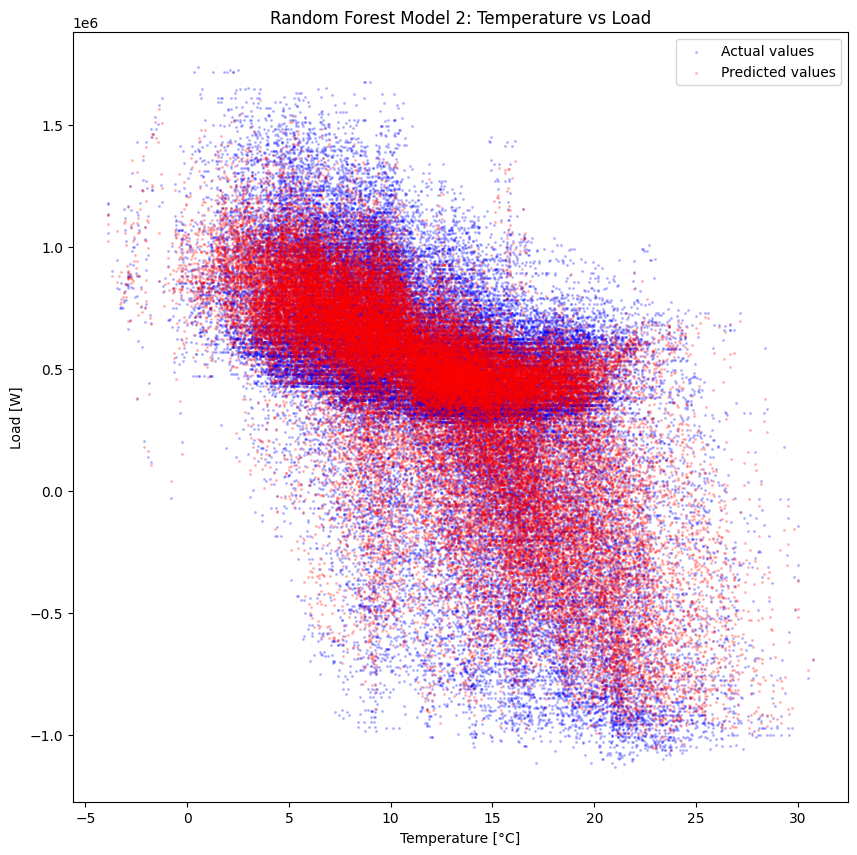

In [170]:
plt.figure(figsize=(10, 10))
plt.scatter(X_test_2['temperature_2m'], y_test_2, s=1.5, color="blue", alpha=0.2, label="Actual values")
plt.scatter(X_test_2['temperature_2m'], y_pred_rf_2, s=1.5, color="red", alpha=0.2, label="Predicted values")
plt.title("Random Forest Model 2: Temperature vs Load")
plt.xlabel("Temperature [°C]")
plt.ylabel("Load [W]")
plt.legend()
plt.show()

While more accurate, and contained within the range of STD around each dot, the new prediction dots still fall below a desired value of at 0.80 for R-square.

### Conclusion and Future Work
While the Random Forest model provided better predictions than Ridge Regression, the R-square values suggest that there is still room for improvement to meet typical meteorological prediction standards (usually above 0.80). Future efforts could explore more advanced techniques or leverage specialized tools like OpenSTEF for short-term energy forecasting, which offers comprehensive machine learning pipelines for enhanced accuracy.